<a href="https://colab.research.google.com/github/hari3747om-bit/NUMPY-CODES/blob/main/Magic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
cols = ["flength","fWidth","fSize","fConc","fConc1","fAsym","fM3Long","fM3trans","fAlpha","fDist"]
df = pd.read_csv("/content/magic04.data", names = cols)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/magic04.data'

In [ ]:
df["fDist"] = (df["fDist"] == "g").astype(int)

In [ ]:
df.head()

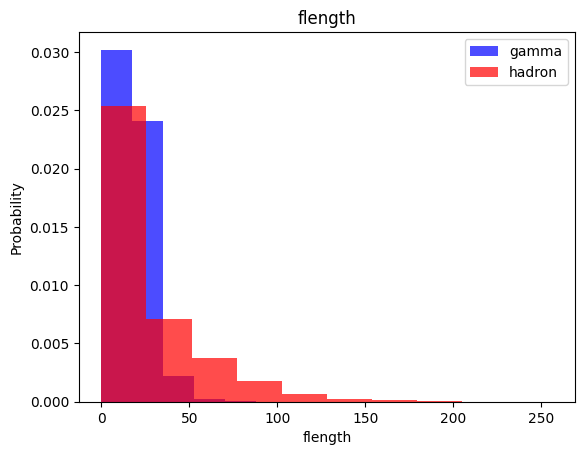

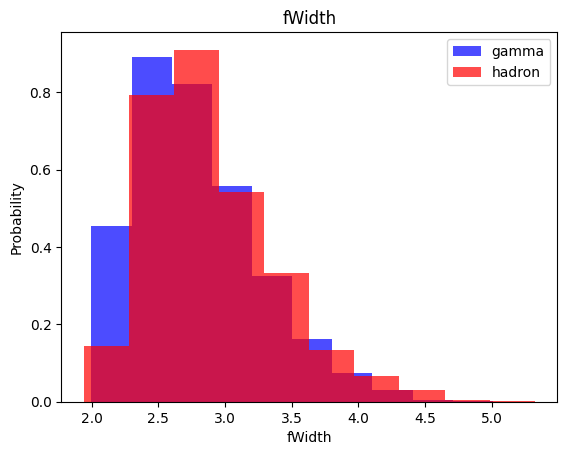

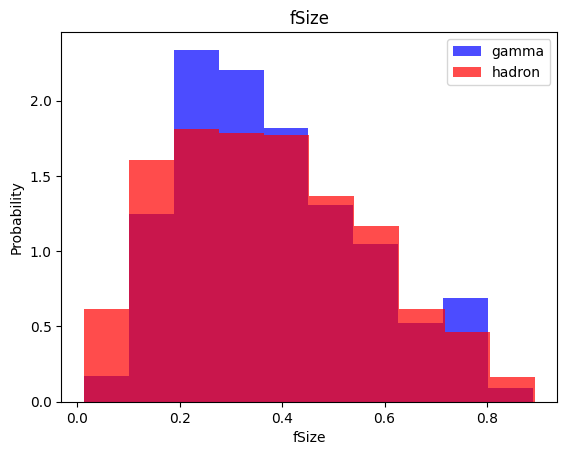

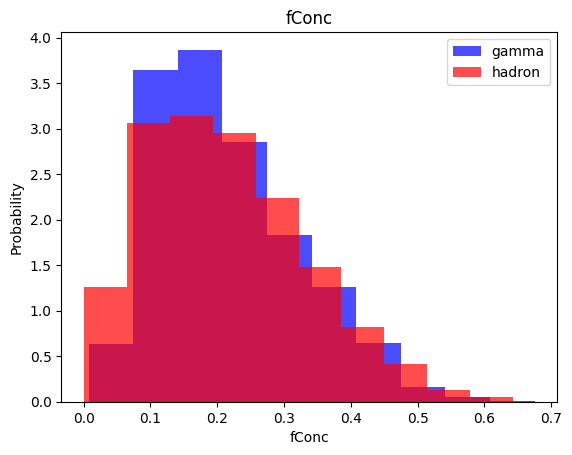

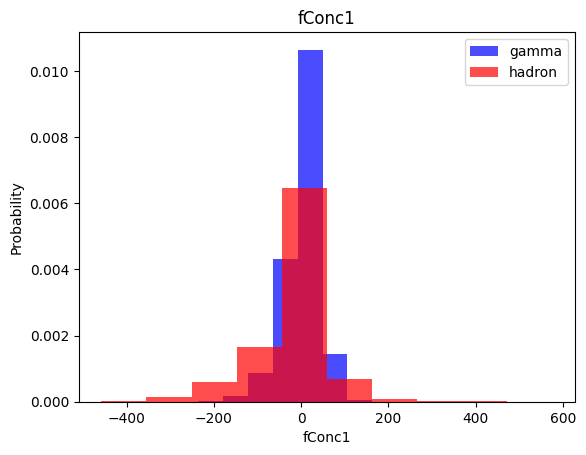

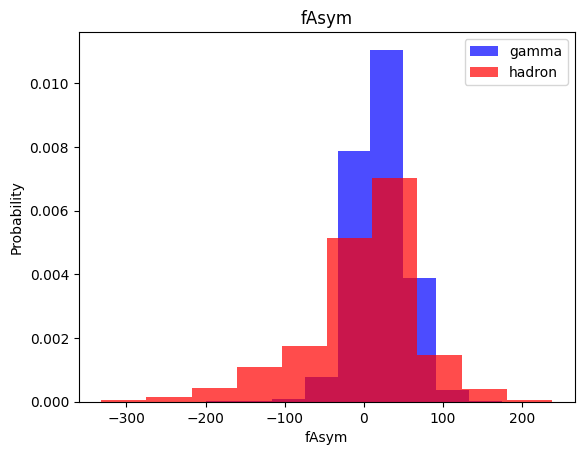

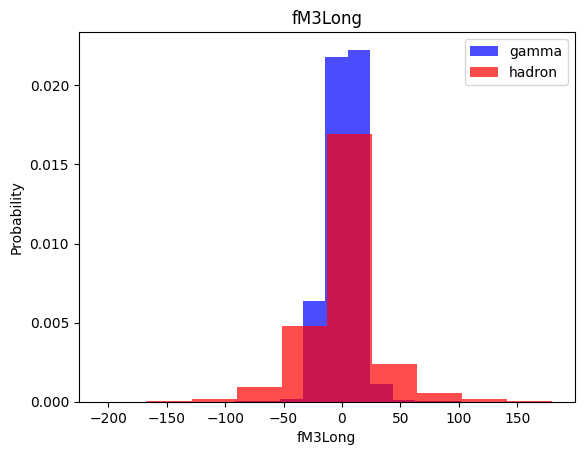

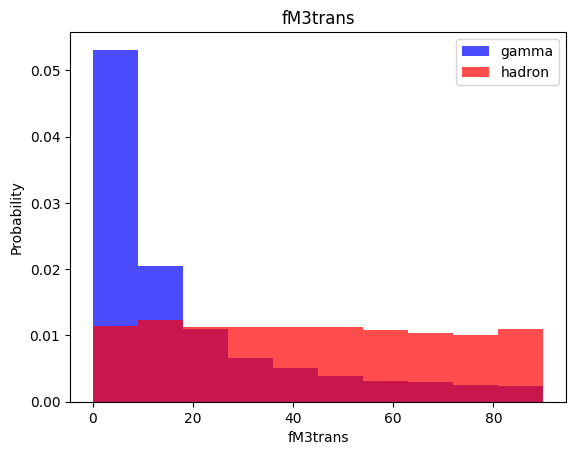

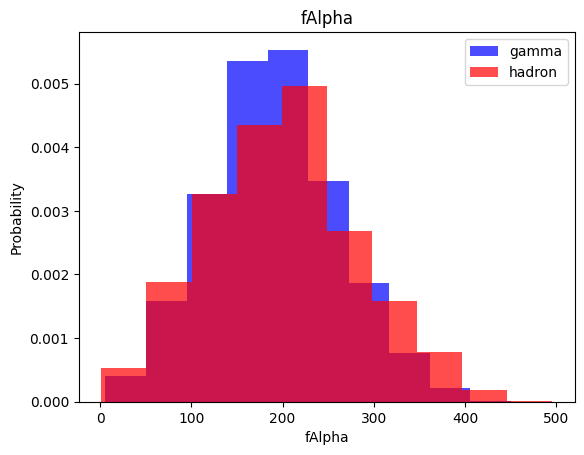

In [8]:
for label in cols[:-1]:
  plt.hist(df[df["fDist"]==1][label],color = "blue",label ="gamma",alpha =0.7, density = True )
  plt.hist(df[df["fDist"]==0][label],color = "red",label ="hadron",alpha =0.7, density = True )
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

In [9]:
train, valid, test = np.split(df.sample(frac=1).reset_index(drop=True), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [16]:
def scale_dataset(dataframe, oversample = False):
  X = dataframe[cols[:-1]].values
  Y = dataframe[cols[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, Y = ros.fit_resample(X,Y)

  data = np.hstack((X,np.reshape(Y,(-1,1))))

  return data, X, Y

In [20]:
train = pd.DataFrame(train, columns=cols)
valid = pd.DataFrame(valid, columns=cols)
test = pd.DataFrame(test, columns=cols)

train, X_train, Y_train = scale_dataset(train, oversample = True)
valid, X_valid, Y_valid = scale_dataset(valid, oversample = False)
test, X_test, Y_test = scale_dataset(test, oversample = False)